In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import glob
import os

FOLDER_DATA = "hasil_csv"
FPS_DETEKSI = 58.05117315825659
G_REFERENSI = 9.8

def hitung_presisi(jalur_file):
    try:
        df = pd.read_csv(jalur_file)

        df['Height_cm'] = df['Height_cm']

        t = (df['Frame_Index'] - df['Frame_Index'].iloc[0]) / FPS_DETEKSI

        y = df['Height_cm'] / 100.0

        def model_glbb(t_val, g_val, v0, y0):
            return y0 + v0 * t_val - 0.5 * g_val * t_val ** 2

        popt, _ = curve_fit(model_glbb, t, y)
        g_observasi = abs(popt[0])

        kecepatan_sesaat = -np.gradient(y, t)

        v_maks_terukur = kecepatan_sesaat.max()

        tinggi_total = y.iloc[0] - y.iloc[-1]
        v_maks_teori_ref = np.sqrt(2 * G_REFERENSI * tinggi_total)
        v_maks_teori_obs = np.sqrt(2 * g_observasi * tinggi_total)

        popt, _ = curve_fit(model_glbb, t, y)
        g_observasi = abs(popt[0])
        v0_observasi = popt[1]
        v_teoritis = g_observasi * t - v0_observasi
        return {
            'File': os.path.basename(jalur_file),
            'g_observasi': round(g_observasi, 3),
            'v_maks_terukur': round(v_maks_terukur, 3),
            'v_maks_teori_ref': round(v_maks_teori_ref, 3),
            'v_maks_teori_obs': round(v_maks_teori_obs, 3),
            'tinggi_jatuh_m': round(tinggi_total, 3)
        }, t, y, kecepatan_sesaat, v_teoritis

    except Exception as e:
        print(f"Gagal memproses file {jalur_file}: {e}")
        return None, None, None, None

daftar_file = glob.glob(os.path.join(FOLDER_DATA, "*.csv"))
# print(daftar_file)
ringkasan_hasil = []

print(f"Memulai analisis pada {len(daftar_file)} file...")

for f in daftar_file:

    hasil, t_plot, y_plot, v_plot, v_teori = hitung_presisi(f)

    if hasil:
        ringkasan_hasil.append(hasil)

        plt.figure(figsize=(12, 5))

        # Jarak vs Waktu
        plt.subplot(1, 2, 1)
        plt.scatter(t_plot, y_plot, color='blue', s=30, label='Data (Bulat)')
        plt.title(f"Grafik Jarak vs Waktu\n{hasil['File']}")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Tinggi (m)")
        plt.grid(True)
        plt.legend()

        # Kecepatan vs Waktu
        plt.subplot(1, 2, 2)
        plt.plot(t_plot, v_plot, marker='o', color='red', linestyle='--')
        plt.title(f"Grafik Kecepatan vs Waktu\nV-Maks: {hasil['v_maks_terukur']} m/s")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Kecepatan (m/s)")
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(f"analisis_{hasil['File']}.png")
        plt.close()

if ringkasan_hasil:
    df_ringkasan = pd.DataFrame(ringkasan_hasil)
    df_ringkasan.to_csv("ringkasan_analisis_fisika.csv", index=False)
    print("\n--- TABEL HASIL PERHITUNGAN ---")
    print(df_ringkasan.to_string(index=False))
    print("\nProses selesai. File 'ringkasan_analisis_fisika.csv' telah dibuat.")


Memulai analisis pada 10 file...

--- TABEL HASIL PERHITUNGAN ---
           File  g_observasi  v_maks_terukur  v_maks_teori_ref  v_maks_teori_obs  tinggi_jatuh_m
    perlima.csv        8.714           4.883             5.422             5.113             1.5
 persepuluh.csv        7.993           4.618             5.422             4.897             1.5
    perenam.csv        8.580           4.900             5.422             5.073             1.5
    persatu.csv        7.739           4.299             5.422             4.818             1.5
persembilan.csv        8.390           4.584             5.422             5.017             1.5
   perempat.csv        7.569           4.691             5.422             4.765             1.5
     perdua.csv        8.751           4.904             5.422             5.124             1.5
    pertiga.csv        8.335           4.537             5.422             5.001             1.5
 perdelapan.csv        7.853           4.565             5.42

In [13]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import glob
import os

# --- KONFIGURASI ---
FOLDER_DATA = "hasil_csv"  # Folder berisi 10 file yang sudah dibersihkan
FPS = 58.05117315825659    # FPS video
G_REF = 9.8                # Referensi teori

def hitung_tiap_file(jalur_file):
    df = pd.read_csv(jalur_file)

    # Menghitung waktu (t) berdasarkan Frame_Index
    # t = (Frame sekarang - Frame pertama) / FPS
    t = (df['Frame_Index'] - df['Frame_Index'].iloc[0]) / FPS
    y = df['Height_cm'] / 100.0  # Konversi ke meter

    # Rumus GLBB: y = y0 + v0*t - 0.5*g*t^2
    def model_glbb(t_val, g_val, v0, y0):
        return y0 + v0 * t_val - 0.5 * g_val * t_val**2

    # Mencari nilai g yang paling pas untuk file ini
    popt, _ = curve_fit(model_glbb, t, y)
    g_obj = abs(popt[0])

    # Menghitung kecepatan maks (v = selisih jarak / selisih waktu)
    v = -np.gradient(y, t)
    v_max = v.max()

    return g_obj, v_max

files = glob.glob(os.path.join(FOLDER_DATA, "*.csv"))
hasil_individu = []

for f in files:
    g, vmax = hitung_tiap_file(f)
    hasil_individu.append({
        'Percobaan': os.path.basename(f),
        'g_m/s2': round(g, 3),
        'v_maks_m/s': round(vmax, 3)
    })

# 1. TABEL PER PERCOBAAN (Untuk Bab Hasil)
df_individu = pd.DataFrame(hasil_individu)
print("--- DATA PER PERCOBAAN ---")
print(df_individu.to_string(index=False))
df_individu.to_csv("hasil_per_percobaan.csv", index=False)

# 2. ANALISIS GABUNGAN (Untuk Bab Analisis/Pembahasan)
g_array = df_individu['g_m/s2'].values
n = len(g_array)
g_rata = np.mean(g_array)
std_dev = np.std(g_array, ddof=1)
k_absolut = std_dev / np.sqrt(n)
k_relatif = (k_absolut / g_rata) * 100
galat = (abs(g_rata - G_REF) / G_REF) * 100

print("\n--- ANALISIS GABUNGAN (STATISTIK) ---")
print(f"Rata-rata g            : {g_rata:.3f} m/s^2")
print(f"Standar Deviasi        : {std_dev:.3f} m")
print(f"Ketidakpastian Absolut : {k_absolut:.3f}")
print(f"Ketidakpastian Relatif : {k_relatif:.2f} %")
print(f"Persentase Galat       : {galat:.2f} %")
print(f"g = ({g_rata:.2f} +/- {k_absolut:.2f}) m/s^2")
print(f"Ketelitian: {100 - k_relatif:.2f} %")

hasil_statistik = {
    'Parameter': [
        'Jumlah Percobaan (n)',
        'Rata-rata g (m/s2)',
        'Standar Deviasi',
        'Ketidakpastian Absolut',
        'Ketidakpastian Relatif (%)',
        'Persentase Galat (%)',
        'Ketelitian (%)'
    ],
    'Nilai': [
        n,
        round(g_rata, 3),
        round(std_dev, 3),
        round(k_absolut, 3),
        round(k_relatif, 2),
        round(galat, 2),
        round(100 - k_relatif, 2)
    ]
}

df_statistik = pd.DataFrame(hasil_statistik)
df_statistik.to_csv("ringkasan_statistik.csv", index=False)

print("\nFile 'hasil_per_percobaan.csv' dan 'ringkasan_statistik.csv' telah berhasil disimpan.")

--- DATA PER PERCOBAAN ---
      Percobaan  g_m/s2  v_maks_m/s
    perlima.csv   8.627       4.859
 persepuluh.csv   8.026       4.628
    perenam.csv   8.436       4.859
    persatu.csv   7.739       4.299
persembilan.csv   8.530       4.622
   perempat.csv   7.736       4.743
     perdua.csv   8.820       4.923
    pertiga.csv   8.418       4.559
 perdelapan.csv   7.873       4.571
   pertujuh.csv   8.700       4.744

--- ANALISIS GABUNGAN (STATISTIK) ---
Rata-rata g            : 8.290 m/s^2
Standar Deviasi        : 0.410 m
Ketidakpastian Absolut : 0.130
Ketidakpastian Relatif : 1.56 %
Persentase Galat       : 15.40 %
g = (8.29 +/- 0.13) m/s^2
Ketelitian: 98.44 %

File 'hasil_per_percobaan.csv' dan 'ringkasan_statistik.csv' telah berhasil disimpan.


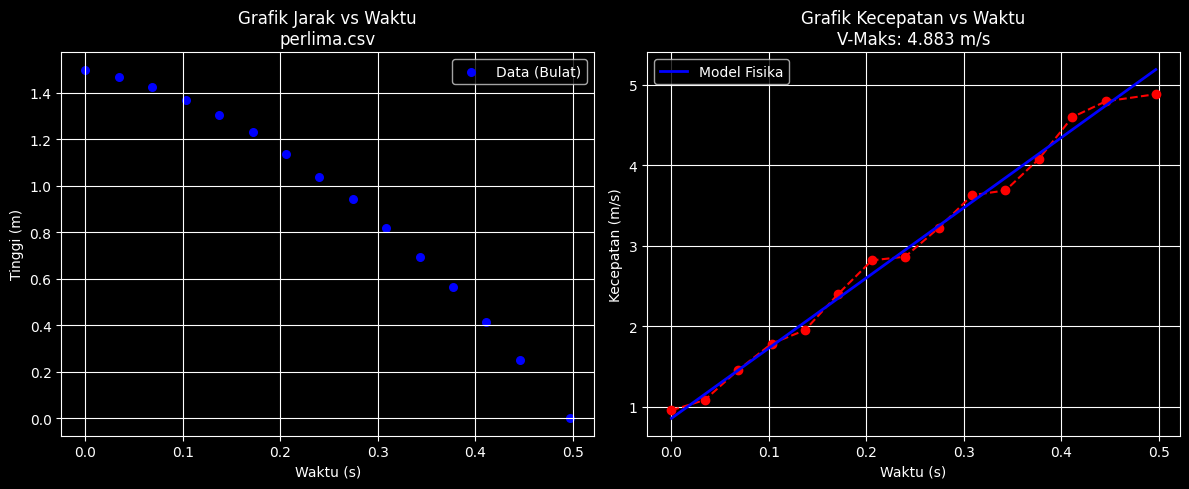

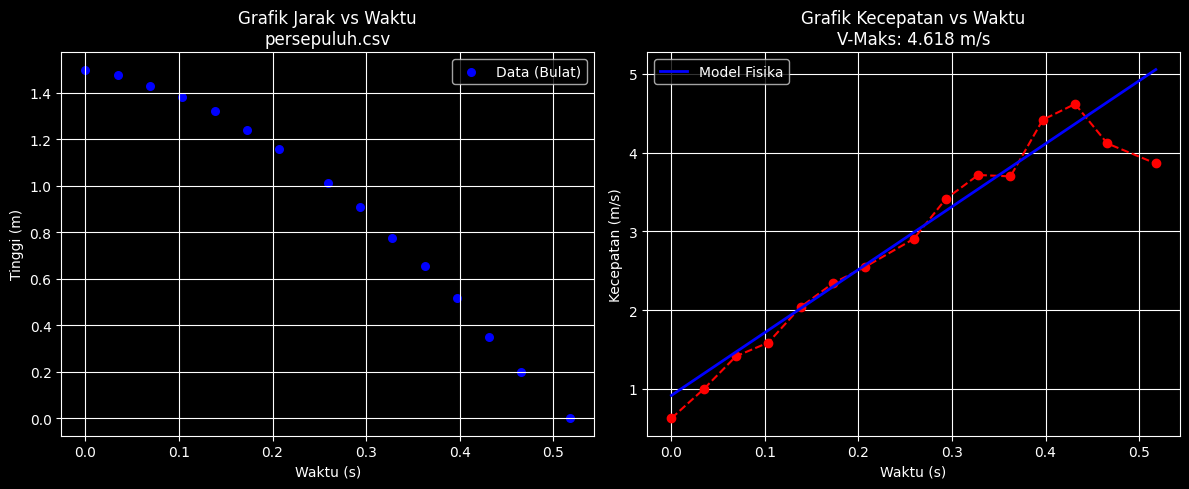

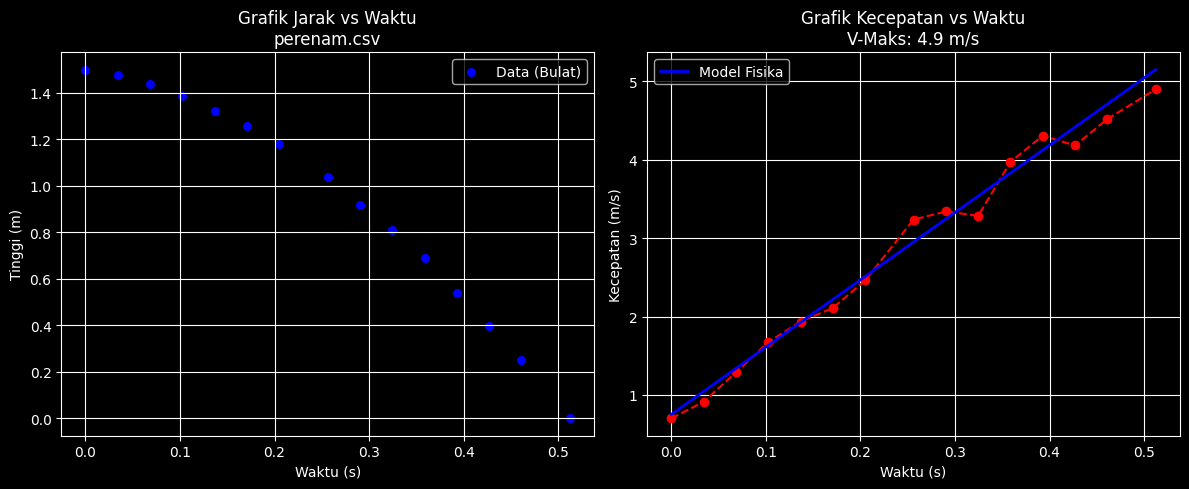

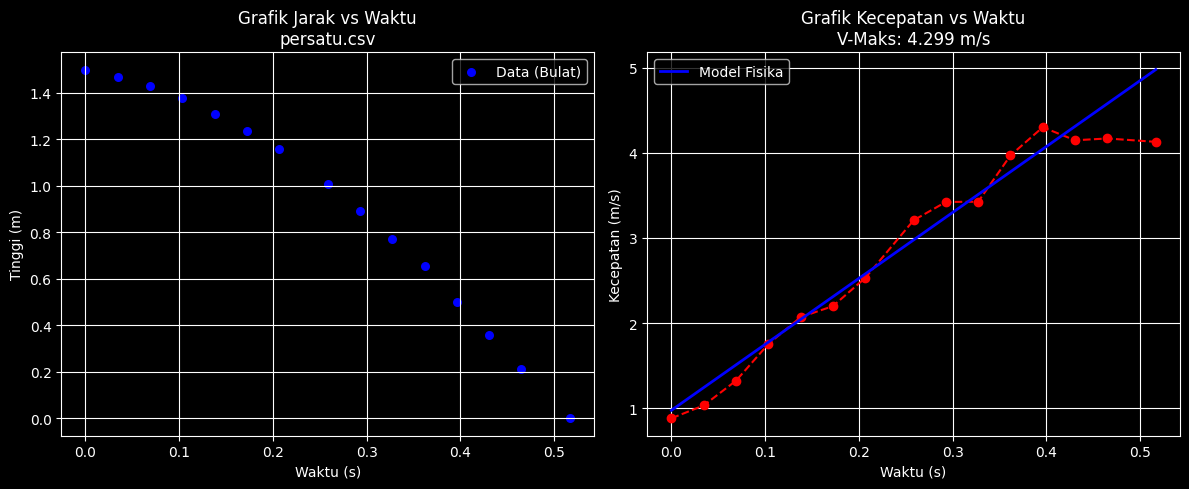

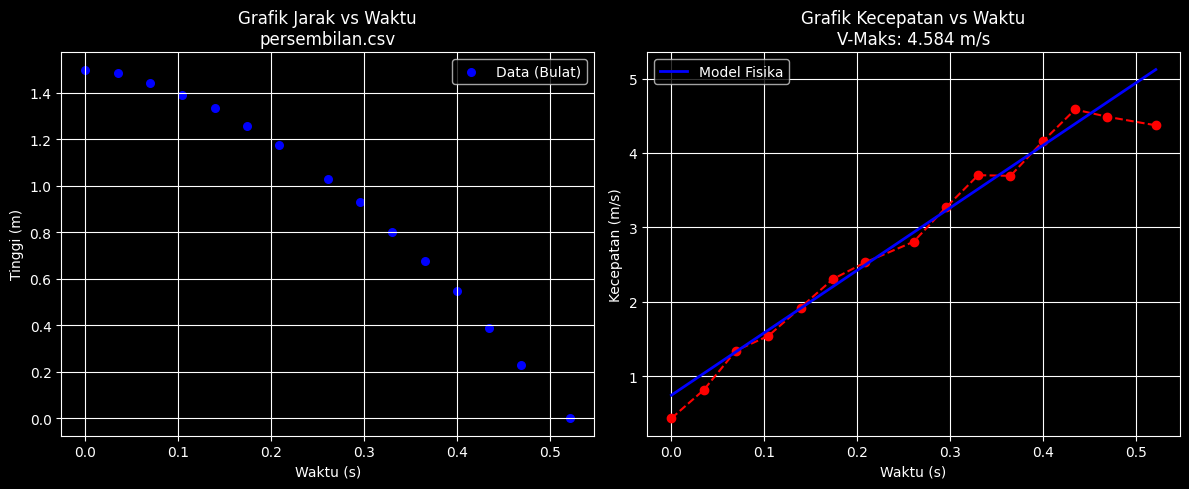

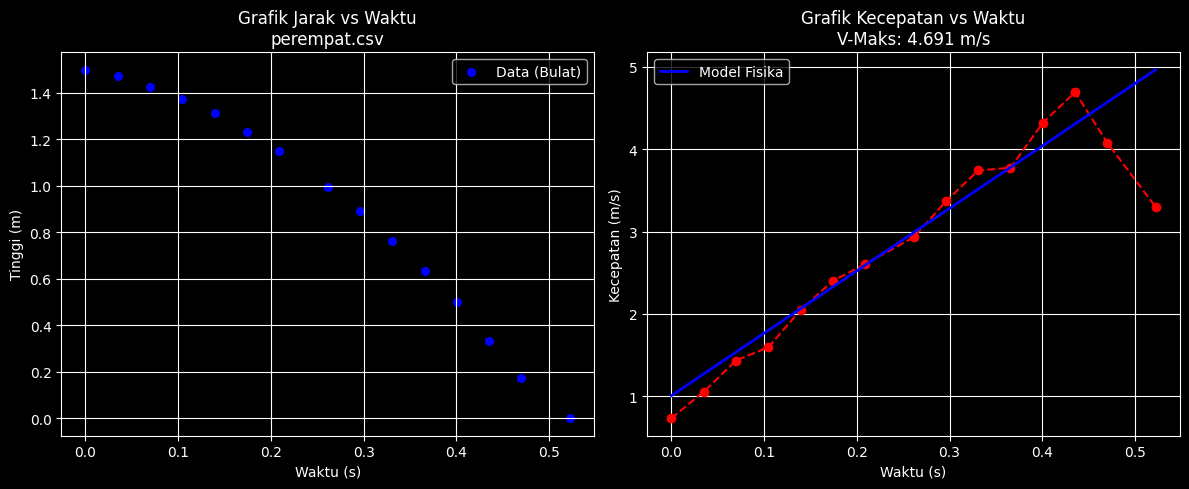

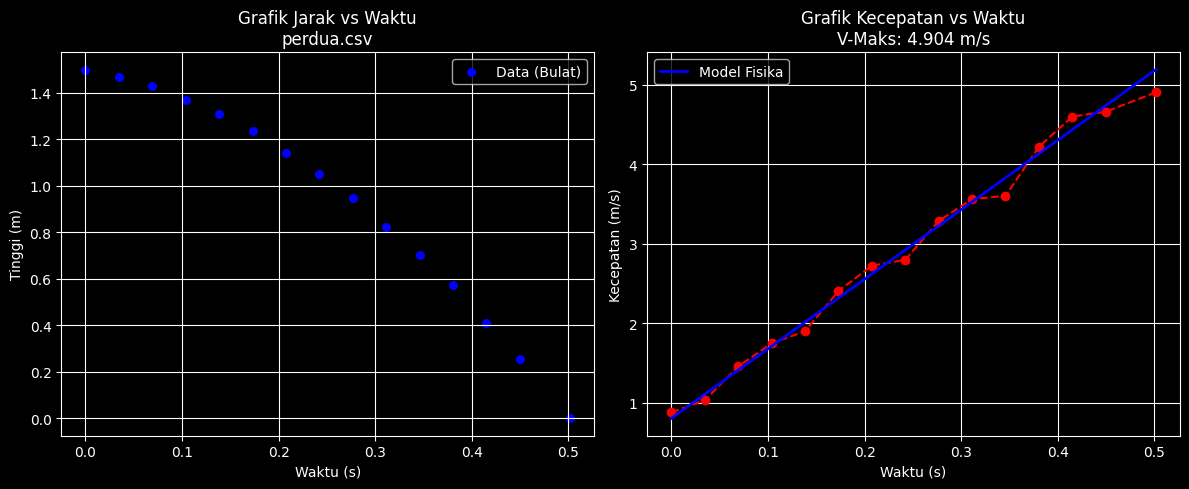

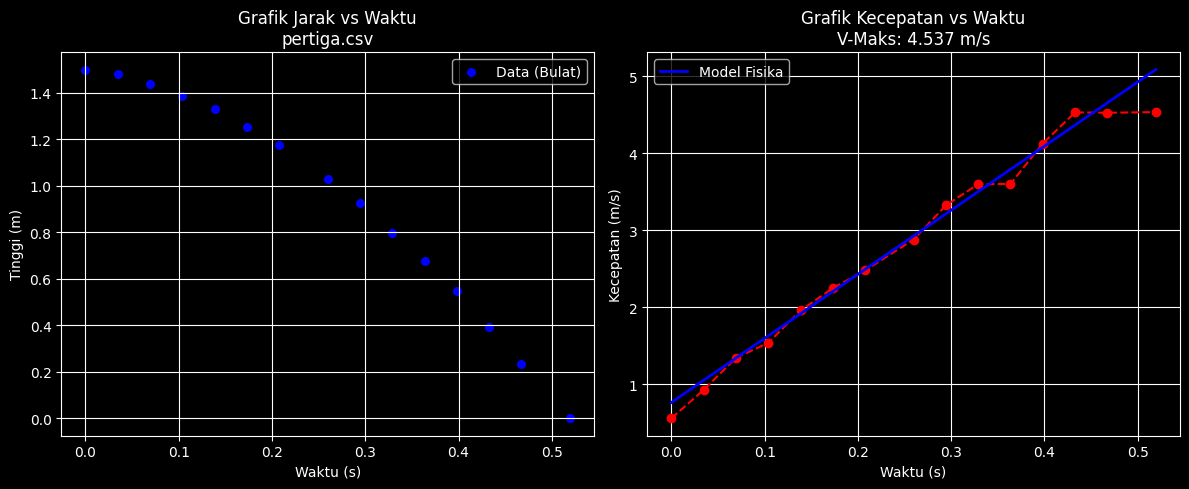

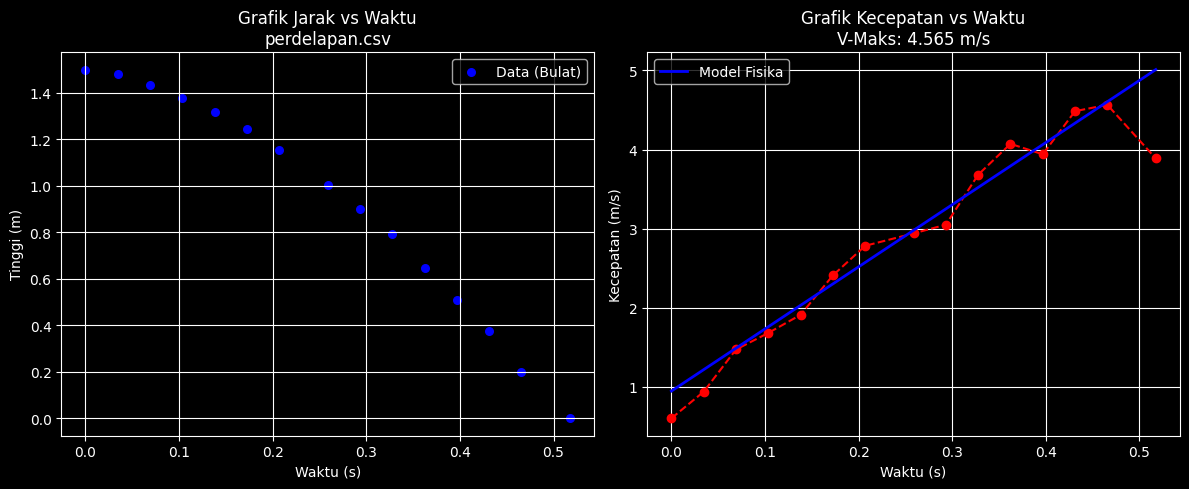

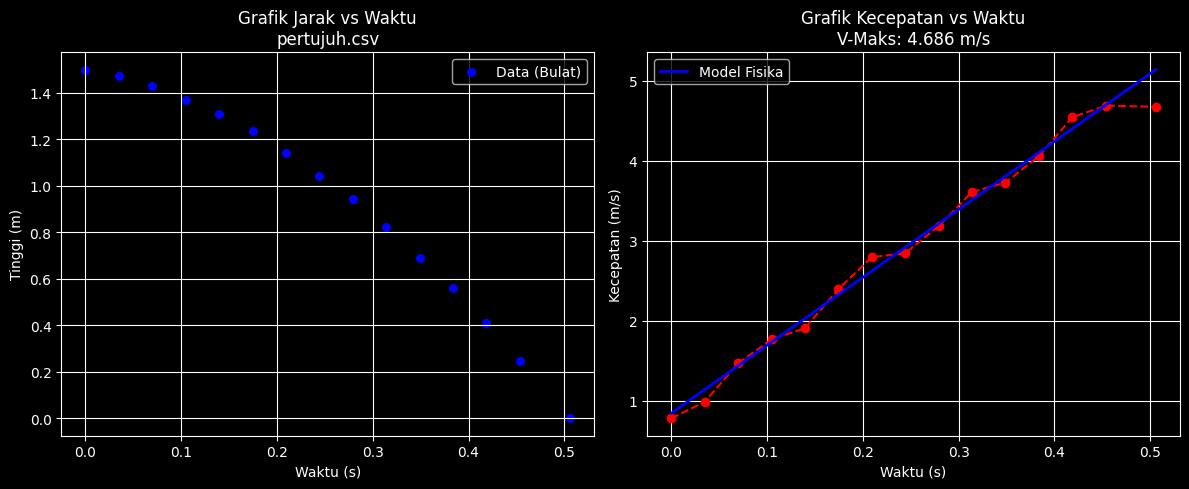

In [16]:
for f in daftar_file:
    hasil, t_plot, y_plot, v_plot, v_teori = hitung_presisi(f)

    if hasil:
        ringkasan_hasil.append(hasil)

        plt.figure(figsize=(12, 5))

        # Jarak vs Waktu
        plt.subplot(1, 2, 1)
        plt.scatter(t_plot, y_plot, color='blue', s=30, label='Data (Bulat)')
        plt.title(f"Grafik Jarak vs Waktu\n{hasil['File']}")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Tinggi (m)")
        plt.grid(True)
        plt.legend()

        # Kecepatan vs Waktu
        plt.subplot(1, 2, 2)
        plt.plot(t_plot, v_plot, marker='o', color='red', linestyle='--')
        plt.plot(t_plot, v_teori, color='blue', linewidth=2, label='Model Fisika')
        plt.title(f"Grafik Kecepatan vs Waktu\nV-Maks: {hasil['v_maks_terukur']} m/s")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Kecepatan (m/s)")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(f"analisis_{hasil['File']}.png")